In [1]:
from datascience import * 
import matplotlib
import numpy as np
import matplotlib.pyplot as plots
path_data = '../../data/data8/'
matplotlib.use('Agg')
%matplotlib inline
plots.style.use('fivethirtyeight')

In [3]:
two_groups = make_array("treatment", "control")
np.random.choice(two_groups)

'treatment'

In [7]:
np.random.choice(two_groups, 10)

array(['treatment', 'control', 'treatment', 'control', 'control',
       'treatment', 'control', 'control', 'treatment', 'control'],
      dtype='<U9')

In [8]:
tosses =  make_array("Tails", "Heads", "Tails", "Heads", "Heads")
tosses == "Heads"

array([False,  True, False,  True,  True], dtype=bool)

In [9]:
np.count_nonzero(tosses == "Heads")

3

In [10]:
def sign(x):
    
    if x > 0:
        return 'Positive'
    
    elif x < 0:
        return 'Negative'
    
    else:
        return 'Neither positive nor negative'

In [11]:
sign(-3)

'Negative'

In [12]:
def one_bet(x):
    """Returns my net gain if the die shows x spots"""
    if x <= 2:
        return -1
    elif x <= 4:
        return 0
    elif x <= 6:
        return 1

In [13]:
one_bet(1), one_bet(2), one_bet(3), one_bet (4), one_bet(5), one_bet(6)

(-1, -1, 0, 0, 1, 1)

In [16]:
one_bet(np.random.choice(np.arange(1, 7)))

0

## Iteration

In [17]:
def bet_on_one_roll():
    """Returns my net gain on one bet"""
    x = np.random.choice(np.arange(1, 7))  # roll a die once and record the number of spots
    if x <= 2:
        return -1
    elif x <= 4:
        return 0
    elif x <= 6:
        return 1

In [18]:
bet_on_one_roll()

0

In [19]:
for i in np.arange(5):
    print(bet_on_one_roll())

1
-1
1
1
1


In [20]:
# betting on 5 rolls
outcomes = make_array()

for i in np.arange(5):
    outcome_of_bet = bet_on_one_roll()
    outcomes = np.append(outcomes, outcome_of_bet)

outcomes

array([ 0.,  1.,  1.,  1.,  0.])

In [21]:
for i in np.arange(300):
    outcome_of_bet = bet_on_one_roll()
    outcomes = np.append(outcomes, outcome_of_bet)

outcomes

array([ 0.,  1.,  1.,  1.,  0.,  1., -1.,  1., -1.,  1.,  0., -1.,  0.,
       -1.,  1.,  0., -1.,  1.,  0.,  1., -1., -1.,  1.,  1.,  1.,  1.,
        1.,  0.,  1., -1.,  1.,  1.,  0.,  1.,  0.,  0.,  1.,  0.,  0.,
        1., -1.,  0.,  0.,  0., -1., -1.,  0.,  1., -1.,  1.,  0.,  1.,
       -1., -1., -1.,  0., -1.,  1.,  0., -1.,  1.,  1.,  0.,  1., -1.,
        0.,  1.,  1., -1.,  1.,  0.,  1.,  0.,  0.,  0., -1.,  1., -1.,
        0.,  0.,  1.,  0.,  0., -1., -1.,  1.,  0.,  1.,  0.,  0.,  0.,
       -1.,  1.,  1.,  0., -1., -1.,  0., -1.,  1.,  0., -1.,  1., -1.,
       -1.,  1.,  1.,  0., -1., -1.,  1., -1., -1., -1.,  1., -1., -1.,
       -1., -1., -1., -1., -1., -1.,  1.,  1.,  1., -1., -1.,  0.,  0.,
        0.,  0., -1.,  0.,  1.,  0.,  1., -1., -1., -1., -1.,  0.,  1.,
        1.,  1.,  0.,  1.,  1., -1.,  0., -1.,  0.,  1.,  0.,  0., -1.,
        1.,  1., -1., -1.,  0.,  0., -1., -1.,  1.,  0.,  0., -1., -1.,
       -1.,  1.,  0.,  0.,  0.,  1.,  0., -1.,  0.,  0., -1.,  0

In [22]:
len(outcomes)

305

In [23]:
np.count_nonzero(outcomes)

202

In [24]:
outcome_table = Table().with_column("Outcome", outcomes)
outcome_table

Outcome
0
1
1
1
0
1
-1
1
-1
1


In [32]:
outcome_table.group("Outcome")

Outcome,count
-1,101
0,103
1,101


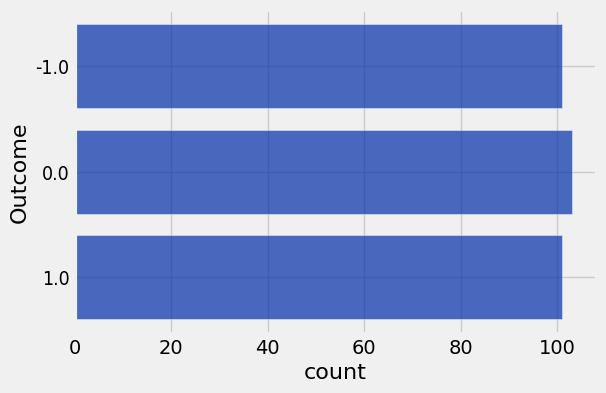

In [31]:
outcome_table.group("Outcome").barh(0)

In [30]:
outcome_table.group("Outcome").pivot("Outcome", "count")

count,-1.0,0.0,1.0
101,1,0,1
103,0,1,0


## Simulation

### Step 1: What to simulate

Decide which quantity you want to simulate. For example, you might decide that you want to simulate the outcomes of tosses of a coin. Each simulated value will be a Head or a Tail.

### Step 2: Simulating One Value

Figure out how to simulate one value of the quantity you specified in Step 1. In our example, you have to figure out how to simulate the outcome of one toss of a coin. 

### Step 3: Number of Repetitions

Decide how many times you want to simulate the quantity. You will have to repeat the simulation in Step 2 that many times. 

### Step 4: Simulating Multiple Values

Finally, put it all together as follows.

- Create an empty array in which to collect all the simulated values. We will call this the collection array.

- Create a “repetitions sequence,” that is, a sequence whose length is the number of repetitions you specified in Step 3. For n repetitions we will almost always use the sequence `np.arange(n)`.

- Create a `for` loop. For each element of the repetitions sequence:

- Simulate one value by using the function you wrote in Step 2.

- Augment the collection array with this simulated value.


### Number of Heads in 100 tosses

* Step 1:  What?
The number of heads in 100 tosses


In [34]:
coin = make_array("Heads", "Tails")

- Step 2: Simulate one value

In [35]:
one_toss = np.random.choice(coin)
one_toss

'Tails'

Need to run several times to get at least one head. Can run the 100 times straight.

In [36]:
outcomes = np.random.choice(coin, 100)
num_heads = np.count_nonzero(outcomes == "Heads")
num_heads

54

In [37]:
# A function to do this for us multiple times
def one_simulated_value():
    outcomes = np.random.choice(coin, 100)
    return np.count_nonzero(outcomes == "Heads")

- Step 3: Multiple reps: 20_000 should be a good start.

  Essentially we toss 100 coins 20,000 times.
 
* Step 4: Simulating multiple values.
  
    We'll need to store them in an array for future use.

In [38]:
num_reps = 20000
heads = make_array()

for i in np.arange(num_reps):
    new_value = one_simulated_value()
    heads = np.append(heads, new_value)

In [39]:
len(heads)

20000

Let's see how the head tosses came out. We can use a histogram for that.

In [41]:
simulation_results = Table().with_columns(
    "Repetition", np.arange(1, num_reps + 1),
    "Number of Heads", heads
)

In [42]:
simulation_results.show(5)

Repetition,Number of Heads
1,50
2,48
3,40
4,53
5,42


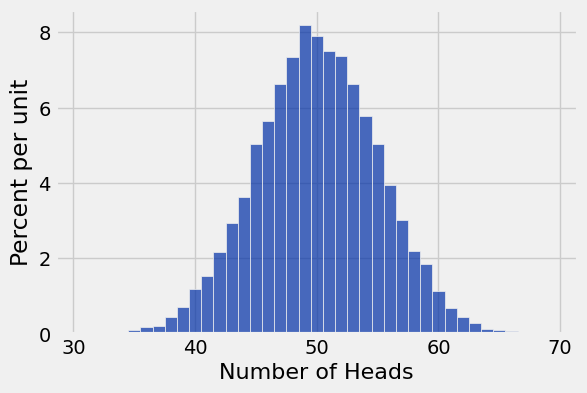

In [43]:
simulation_results.hist("Number of Heads", bins=np.arange(30.5, 69.6, 1))

In [46]:
min(heads), max(heads)

(30.0, 69.0)

Each bin has width 1 and is centered at each value of the number of heads.

While in theory it is possible that the number of heads can be anywhere between 0 and 100, the simulation shows that the range of probable values is much smaller.

The histogram also shows that in almost all of the repetitions, the number of heads in 100 tosses was somewhere between 35 and 65. Indeed, the bulk of the repetitions produced numbers of heads in the range 45 to 55.

In [48]:
simulation_results.where("Number of Heads", 69.0)

Repetition,Number of Heads
1932,69


### Moves in Monopoly

Two dice rolls determine your one move.

In [49]:
die = np.arange(1, 7)
sum(np.random.choice(die, 2))

6

In [50]:
def one_simulated_move():
    return sum(np.random.choice(die, 2))
    

In [51]:
num_repetitions = 10000

moves = make_array()
for i in np.arange(num_repetitions):
    new_move = one_simulated_move()
    moves = np.append(moves, new_move)

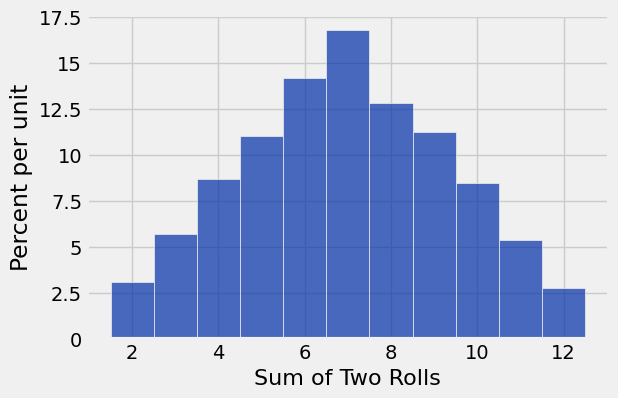

In [52]:
results = Table().with_columns(
    "Repetition", np.arange(1, num_repetitions + 1),
    "Sum of Two Rolls", moves
)

results.hist("Sum of Two Rolls", bins=np.arange(1.5, 12.6, 1))